### Mini Project 1: Text Analysis

#### 1. Project Goals
The goal of this project is to explore author word choice/frequency and style through text analysis using works from Project Gutenberg. I plan to analyze:
* **Genre Influence:** How do an author's word choices, sentence lengths, and potentially structural patterns change when writing across two different genres?
* **Author Differences:** How do two different authors writing within the same genre compare in their vocabulary preferences and writing styles?

#### 2. Data Sources
I will pull plain-text files from Project Gutenberg for our analysis:
* **Robert Louis Stevenson (Genre Comparison):** Two books by the same author written in different genres. Strange Case of Dr Jekyll and Mr Hyde (Gothic Horror/Fiction) and Treasure Island (Adventure).
* **Robert Louis Stevenson & Bram Stoker (Genre Control Comparison):** Two different authors who wrote works within the same shared genre as a baseline comparison (Gothic Horror/Fiction).

#### 3. Methodology & Metrics
I plan to analyze the following to look at genre influence and author differences:
* **Word Frequencies & Vocabulary:** Comparing high-frequency words, unique word counts, and potential author-specific preferences (such as specific functional or lexical words).
* **Sentence Length Distribution:** Calculating and comparing the average length and variance of sentences across texts.
* **Dialogue Density:** Estimating the amount of conversational text by counting quotation marks or dialogue markers.

#### 4. Expected Comparisons
* Compare word frequencies between the two books of our primary single author.
* Compare word frequencies and structural styles between the two separate authors.
* *(Optional Extra Credit)* Investigate whether specific target words (like "would") follow a binomial distribution across different books.

In [4]:
import requests, re, nltk
from bs4 import BeautifulSoup
from collections import Counter
import operator
import numpy as np
import pylab
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize

In [5]:
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014', '', "'''", '``', '—']

# We most likely would like to remove html markup
def cleanHtml (html):
    soup = BeautifulSoup(html, 'html.parser')
    return soup.get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)

def get_wf (URL):
    # First get the web page
    r = requests.get(URL)
    
    # Remove html markup and lowercase
    t = cleanHtml(r.text).lower()
    
    # Slice out Project Gutenberg header and footer text
    start_marker = "*** start of the project gutenberg"
    end_marker = "*** end of the project gutenberg"
    
    start_pos = t.find(start_marker)
    end_pos = t.find(end_marker)
    
    # If the markers are found, slice the string between them
    if start_pos != -1 and end_pos != -1:
        # Move start_pos forward past the header line itself
        start_pos = t.find('\n', start_pos)
        t = t[start_pos:end_pos]
    
    # Split string into an array of words using any sequence of spaces "\s+" 
    wds = re.split('\s+', t)
    
    # Remove periods, commas, etc. stuck to the edges of words
    for i in range(len(wds)):
        wds[i] = cleanWord(wds[i])
    
    # Calculate frequencies using Counter
    wf = Counter(wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf.pop(k, None)
        
    # How many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
         
    # Get ordered list
    wfs = sorted(wf.items(), key=operator.itemgetter(1), reverse=True)
    ml = min(len(wfs), 15)

    # Reverse the list because barh plots items from the bottom
    return (wfs[0:ml][::-1], tw)

def count_total_words(text):
  t = cleanHtml(text).lower()

  start_marker = '*** start of the project gutenberg'
  end_marker = '*** end of the project gutenberg'

  start_pos = t.find(start_marker)
  end_pos = t.find(end_marker)

  if start_pos != -1 and end_pos != -1:
    start_pos = t.find('\n', start_pos)
    t = t[start_pos:end_pos]
  elif start_pos != -1:
    start_pos = t.find('\n', start_pos)
    t = t[start_pos:]
  elif end_pos != -1:
    t = t[:end_pos]

  sentences = sent_tokenize(t)
  total_words = 0

  for sentence in sentences:
    tokens = word_tokenize(sentence)
    words = [cleanWord(word) for word in tokens if re.search(r'[a-z]', word)]
    total_words += len(words)

  return total_words

[nltk_data] Downloading package stopwords to /home/avery-
[nltk_data]     stubbings/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Same Author Robert Louis Stevenson Book Titles

* Dr. Jekyll and Mr. Hyde
* Treasure Island

In [6]:
(wf_jh, tw_jh) = get_wf('https://www.gutenberg.org/cache/epub/43/pg43.txt')
(wf_ti, tw_ti) = get_wf('https://www.gutenberg.org/cache/epub/120/pg120.txt')

r_jh = requests.get('https://www.gutenberg.org/cache/epub/43/pg43.txt')
total_words_jh = count_total_words(r_jh.text)
r_ti = requests.get('https://www.gutenberg.org/cache/epub/120/pg120.txt')
total_words_ti = count_total_words(r_ti.text)

print(f'Dr. Jekyll and Mr. Hyde - Total words: {total_words_jh}')
print(f'Treasure Island - Total words: {total_words_ti}')

print(f'Dr. Jekyll and Mr. Hyde - Total non-stop words (tw): {tw_jh}')
print(f'\nTreasure Island - Total non-stop words (tw): {tw_ti}')

ratio_jh = tw_jh / total_words_jh
ratio_ti = tw_ti / total_words_ti

print(f'Dr. Jekyll and Mr. Hyde - Non-stop to Total Words Ratio: {ratio_jh:.4f}')
print(f'Treasure Island - Non-stop to Total Words Ratio: {ratio_ti:.4f}')

Dr. Jekyll and Mr. Hyde - Total words: 25891
Treasure Island - Total words: 70043
Dr. Jekyll and Mr. Hyde - Total non-stop words (tw): 12438

Treasure Island - Total non-stop words (tw): 33628
Dr. Jekyll and Mr. Hyde - Non-stop to Total Words Ratio: 0.4804
Treasure Island - Non-stop to Total Words Ratio: 0.4801


In [7]:
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(12, 6))
    f.suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax.spines['top'].set_color ('none')
    ax.spines['bottom'].set_color ('none')
    ax.spines['left'].set_color ('none')
    ax.spines['right'].set_color ('none')
    ax.tick_params (labelcolor='w', top=False, bottom=False, left=False, right=False, labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f.add_subplot (121)
    plt.subplots_adjust (wspace=.5)

    pos = np.arange (len(wf_ee)) 
    ax1.tick_params (axis='both', which='major', labelsize=14)
    pylab.yticks (pos, [ x [0] for x in wf_ee ])
    ax1.barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')
    ax1.set_title("Dr. Jekyll and Mr. Hyde", fontsize=16)

    ax2 = f.add_subplot (122)
    ax2.tick_params (axis='both', which='major', labelsize=14)
    pos = np.arange (len(wf_bu)) 
    pylab.yticks (pos, [ x [0] for x in wf_bu ])
    ax2.barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')
    ax2.set_title("Treasure Island", fontsize=16)

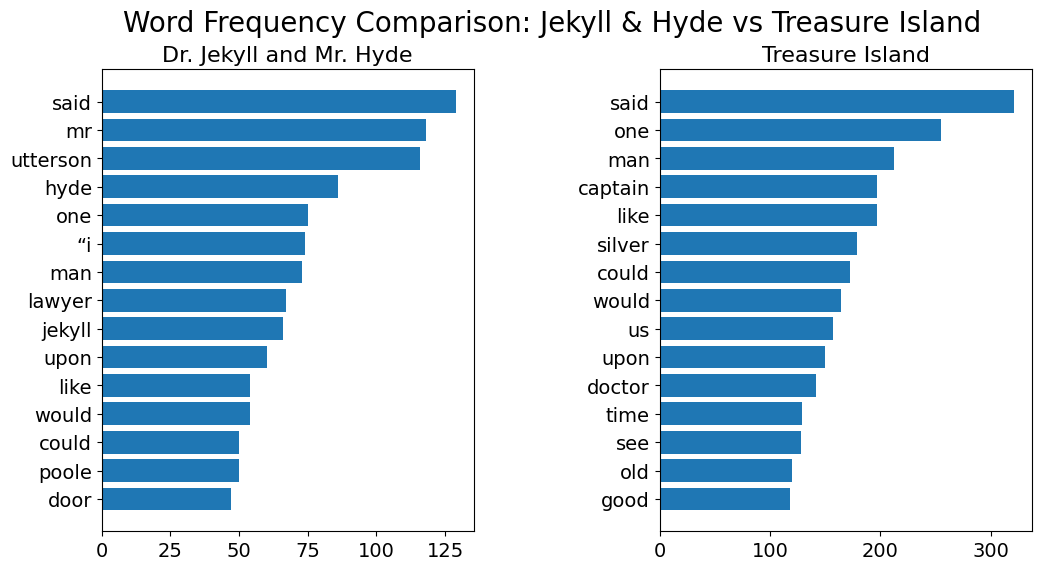

In [8]:
plotTwoLists (wf_jh, wf_ti, 'Word Frequency Comparison: Jekyll & Hyde vs Treasure Island')

In [9]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

/home/avery-stubbings/miniconda3/envs/cosc545/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/avery-stubbings/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt to /home/avery-
[nltk_data]     stubbings/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/avery-
[nltk_data]     stubbings/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/avery-stubbings/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [10]:
def analyze_text_metrics(text):
  t = cleanHtml(text).lower()

  start_marker = '*** start of the project gutenberg'
  end_marker = '*** end of the project gutenberg'

  start_pos = t.find(start_marker)
  end_pos = t.find(end_marker)

  if start_pos != -1 and end_pos != -1:
    start_pos = t.find('\n', start_pos)
    t = t[start_pos:end_pos]
  elif start_pos != -1:
    start_pos = t.find('\n', start_pos)
    t = t[start_pos:]
  elif end_pos != -1:
    t = t[:end_pos]

  sentences = sent_tokenize(t)
  length_counts = Counter()
  overall_pos_counts = Counter()
  sentence_pos_profile_counts = Counter()
  sentences_with_quotes = 0

  # Regex to detect common quotation marks (straight and curly)
  quote_pattern = re.compile(r'["“"„«»‘’]')

  for sentence in sentences:
    if quote_pattern.search(sentence):
      sentences_with_quotes += 1

    tokens = word_tokenize(sentence)
    words = [cleanWord(word) for word in tokens if re.search(r'[a-z]', word)]

    sentence_len = len(words)
    if sentence_len > 0:
      length_counts[sentence_len] += 1

    if sentence_len < 2:
      continue

    pos_tags = nltk.pos_tag(words)

    # Calculate unordered POS counts for this specific sentence
    sentence_pos_counts = Counter()
    for word, tag in pos_tags:
      overall_pos_counts[tag] += 1
      sentence_pos_counts[tag] += 1

    # Create a hashable profile based on POS counts (ignoring word order)
    pos_profile = tuple(sorted(sentence_pos_counts.items()))
    sentence_pos_profile_counts[pos_profile] += 1

  return (
      length_counts,
      overall_pos_counts,
      sentence_pos_profile_counts,
      sentences_with_quotes,
      len(sentences),
  )

In [11]:
# --- Run for Dr. Jekyll and Mr. Hyde ---
r_jh = requests.get('https://www.gutenberg.org/cache/epub/43/pg43.txt')
(
    sentence_lengths_jh,
    overall_pos_jh,
    sentence_profiles_jh,
    quote_count_jh,
    total_sentences_jh,
) = analyze_text_metrics(r_jh.text)

total_words_jh = sum(length * count for length, count in sentence_lengths_jh.items())
sentence_to_word_ratio_jh = total_sentences_jh / total_words_jh if total_words_jh > 0 else 0
dialogue_sentence_ratio_jh = quote_count_jh / total_sentences_jh if total_sentences_jh > 0 else 0

print("=== Dr. Jekyll and Mr. Hyde ===")
print(f'Total sentences: {total_sentences_jh}')
print(f'Total words: {total_words_jh}')
print(f'Sentences containing dialogue/quotes: {quote_count_jh}')
print(f'Sentence-to-word ratio: {sentence_to_word_ratio_jh:.4f}')
print(f'Dialogue-to-sentence ratio: {dialogue_sentence_ratio_jh:.4f} ({dialogue_sentence_ratio_jh * 100:.1f}%)\n')

print('Most common sentence lengths (word count: frequency):')
for length, count in sentence_lengths_jh.most_common(5):
    print(f'{length} words: {count} sentences')

print('\nMost common unordered sentence POS profiles:')
for profile, count in sentence_profiles_jh.most_common(5):
    profile_str = ', '.join([f'{tag}: {qty}' for tag, qty in profile])
    print(f'Count: {count} -> [{profile_str}]')


# --- Run for Treasure Island ---
r_ti = requests.get('https://www.gutenberg.org/cache/epub/120/pg120.txt')
(
    sentence_lengths_ti,
    overall_pos_ti,
    sentence_profiles_ti,
    quote_count_ti,
    total_sentences_ti,
) = analyze_text_metrics(r_ti.text)

total_words_ti = sum(length * count for length, count in sentence_lengths_ti.items())
sentence_to_word_ratio_ti = total_sentences_ti / total_words_ti if total_words_ti > 0 else 0
dialogue_sentence_ratio_ti = quote_count_ti / total_sentences_ti if total_sentences_ti > 0 else 0

print("\n\n=== Treasure Island ===")
print(f'Total sentences: {total_sentences_ti}')
print(f'Total words: {total_words_ti}')
print(f'Sentences containing dialogue/quotes: {quote_count_ti}')
print(f'Sentence-to-word ratio: {sentence_to_word_ratio_ti:.4f}')
print(f'Dialogue-to-sentence ratio: {dialogue_sentence_ratio_ti:.4f} ({dialogue_sentence_ratio_ti * 100:.1f}%)\n')

print('Most common sentence lengths (word count: frequency):')
for length, count in sentence_lengths_ti.most_common(5):
    print(f'{length} words: {count} sentences')

print('\nMost common unordered sentence POS profiles:')
for profile, count in sentence_profiles_ti.most_common(5):
    profile_str = ', '.join([f'{tag}: {qty}' for tag, qty in profile])
    print(f'Count: {count} -> [{profile_str}]')

=== Dr. Jekyll and Mr. Hyde ===
Total sentences: 1187
Total words: 25891
Sentences containing dialogue/quotes: 472
Sentence-to-word ratio: 0.0458
Dialogue-to-sentence ratio: 0.3976 (39.8%)

Most common sentence lengths (word count: frequency):
9 words: 47 sentences
11 words: 45 sentences
6 words: 44 sentences
2 words: 44 sentences
5 words: 43 sentences

Most common unordered sentence POS profiles:
Count: 12 -> [PRP: 1, VBD: 1]
Count: 7 -> [NN: 1, VBD: 1]
Count: 7 -> [NN: 2]
Count: 4 -> [DT: 1, NN: 1, VBN: 1]
Count: 3 -> [NN: 1, VBN: 1]


=== Treasure Island ===
Total sentences: 4128
Total words: 70043
Sentences containing dialogue/quotes: 1636
Sentence-to-word ratio: 0.0589
Dialogue-to-sentence ratio: 0.3963 (39.6%)

Most common sentence lengths (word count: frequency):
8 words: 174 sentences
9 words: 165 sentences
10 words: 156 sentences
7 words: 152 sentences
5 words: 150 sentences

Most common unordered sentence POS profiles:
Count: 28 -> [PRP: 1, VBD: 1]
Count: 27 -> [DT: 1, NN: 1,

### Different Author Robert Louis Stevenson vs Bram Stoker (Gothic Fiction)

* Dr. Jekyll and Mr. Hyde
* Dracula

In [20]:
# Extract counts and totals for Dr. Jekyll and Mr. Hyde and Dracula
(wf_jh, tw_jh) = get_wf('https://www.gutenberg.org/cache/epub/43/pg43.txt')
(wf_dr, tw_dr) = get_wf('https://www.gutenberg.org/cache/epub/345/pg345.txt')

r_jh = requests.get('https://www.gutenberg.org/cache/epub/43/pg43.txt')
total_words_jh = count_total_words(r_jh.text)
r_dr = requests.get('https://www.gutenberg.org/cache/epub/345/pg345.txt')
total_words_dr = count_total_words(r_dr.text)

print(f'Dr. Jekyll and Mr. Hyde - Total words: {total_words_jh}')
print(f'Dracula - Total words: {total_words_dr}')

print(f'Dr. Jekyll and Mr. Hyde - Total non-stop words (tw): {tw_jh}')
print(f'Dracula - Total non-stop words (tw): {tw_dr}')

ratio_jh = tw_jh / total_words_jh
ratio_dr = tw_dr / total_words_dr

print(f'Dr. Jekyll and Mr. Hyde - Non-stop to Total Words Ratio: {ratio_jh:.4f}')
print(f'Dracula - Non-stop to Total Words Ratio: {ratio_dr:.4f}')

Dr. Jekyll and Mr. Hyde - Total words: 25891
Dracula - Total words: 162533
Dr. Jekyll and Mr. Hyde - Total non-stop words (tw): 12438
Dracula - Total non-stop words (tw): 73534
Dr. Jekyll and Mr. Hyde - Non-stop to Total Words Ratio: 0.4804
Dracula - Non-stop to Total Words Ratio: 0.4524


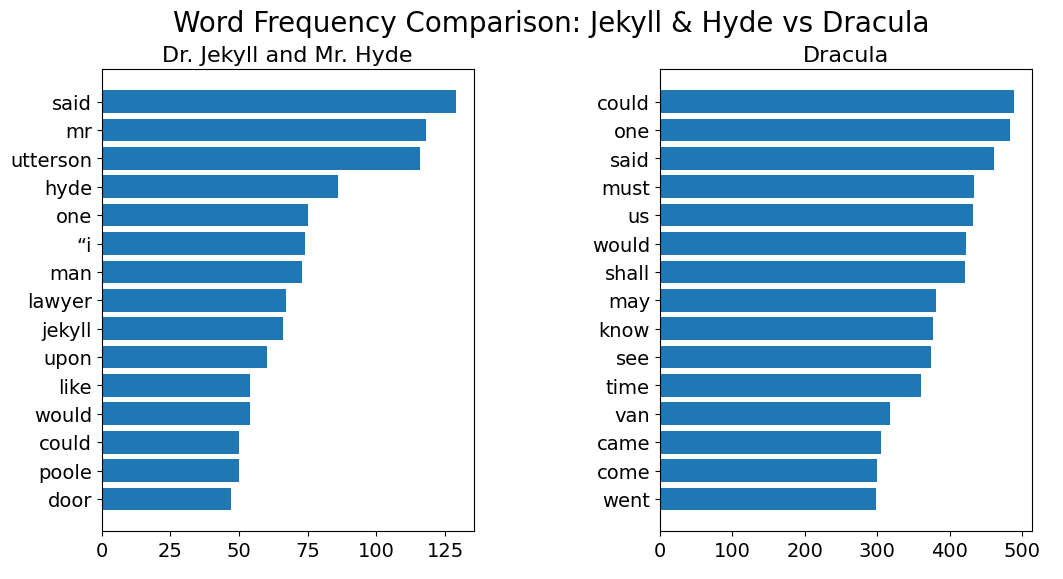

In [21]:
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(12, 6))
    f.suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax.spines['top'].set_color ('none')
    ax.spines['bottom'].set_color ('none')
    ax.spines['left'].set_color ('none')
    ax.spines['right'].set_color ('none')
    ax.tick_params (labelcolor='w', top=False, bottom=False, left=False, right=False, labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f.add_subplot (121)
    plt.subplots_adjust (wspace=.5)

    pos = np.arange (len(wf_ee)) 
    ax1.tick_params (axis='both', which='major', labelsize=14)
    pylab.yticks (pos, [ x [0] for x in wf_ee ])
    ax1.barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')
    ax1.set_title("Dr. Jekyll and Mr. Hyde", fontsize=16)

    ax2 = f.add_subplot (122)
    ax2.tick_params (axis='both', which='major', labelsize=14)
    pos = np.arange (len(wf_bu)) 
    pylab.yticks (pos, [ x [0] for x in wf_bu ])
    ax2.barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')
    ax2.set_title("Dracula", fontsize=16)

plotTwoLists(wf_jh, wf_dr, 'Word Frequency Comparison: Jekyll & Hyde vs Dracula')


In [22]:
# --- Run for Dr. Jekyll and Mr. Hyde ---
r_jh = requests.get('https://www.gutenberg.org/cache/epub/43/pg43.txt')
(
    sentence_lengths_jh,
    overall_pos_jh,
    sentence_profiles_jh,
    quote_count_jh,
    total_sentences_jh,
) = analyze_text_metrics(r_jh.text)

total_words_jh = sum(length * count for length, count in sentence_lengths_jh.items())
sentence_to_word_ratio_jh = total_sentences_jh / total_words_jh if total_words_jh > 0 else 0
dialogue_sentence_ratio_jh = quote_count_jh / total_sentences_jh if total_sentences_jh > 0 else 0

print("=== Dr. Jekyll and Mr. Hyde ===")
print(f'Total sentences: {total_sentences_jh}')
print(f'Total words: {total_words_jh}')
print(f'Sentences containing dialogue/quotes: {quote_count_jh}')
print(f'Sentence-to-word ratio: {sentence_to_word_ratio_jh:.4f}')
print(f'Dialogue-to-sentence ratio: {dialogue_sentence_ratio_jh:.4f} ({dialogue_sentence_ratio_jh * 100:.1f}%)\n')

print('Most common sentence lengths (word count: frequency):')
for length, count in sentence_lengths_jh.most_common(5):
    print(f'{length} words: {count} sentences')

print('\nMost common unordered sentence POS profiles:')
for profile, count in sentence_profiles_jh.most_common(5):
    profile_str = ', '.join([f'{tag}: {qty}' for tag, qty in profile])
    print(f'Count: {count} -> [{profile_str}]')


# --- Run for Dracula ---
r_dr = requests.get('https://www.gutenberg.org/cache/epub/345/pg345.txt')
(
    sentence_lengths_dr,
    overall_pos_dr,
    sentence_profiles_dr,
    quote_count_dr,
    total_sentences_dr,
) = analyze_text_metrics(r_dr.text)

total_words_dr = sum(length * count for length, count in sentence_lengths_dr.items())
sentence_to_word_ratio_dr = total_sentences_dr / total_words_dr if total_words_dr > 0 else 0
dialogue_sentence_ratio_dr = quote_count_dr / total_sentences_dr if total_sentences_dr > 0 else 0

print("\n\n=== Dracula ===")
print(f'Total sentences: {total_sentences_dr}')
print(f'Total words: {total_words_dr}')
print(f'Sentences containing dialogue/quotes: {quote_count_dr}')
print(f'Sentence-to-word ratio: {sentence_to_word_ratio_dr:.4f}')
print(f'Dialogue-to-sentence ratio: {dialogue_sentence_ratio_dr:.4f} ({dialogue_sentence_ratio_dr * 100:.1f}%)\n')

print('Most common sentence lengths (word count: frequency):')
for length, count in sentence_lengths_dr.most_common(5):
    print(f'{length} words: {count} sentences')

print('\nMost common unordered sentence POS profiles:')
for profile, count in sentence_profiles_dr.most_common(5):
    profile_str = ', '.join([f'{tag}: {qty}' for tag, qty in profile])
    print(f'Count: {count} -> [{profile_str}]')

=== Dr. Jekyll and Mr. Hyde ===
Total sentences: 1187
Total words: 25891
Sentences containing dialogue/quotes: 472
Sentence-to-word ratio: 0.0458
Dialogue-to-sentence ratio: 0.3976 (39.8%)

Most common sentence lengths (word count: frequency):
9 words: 47 sentences
11 words: 45 sentences
6 words: 44 sentences
2 words: 44 sentences
5 words: 43 sentences

Most common unordered sentence POS profiles:
Count: 12 -> [PRP: 1, VBD: 1]
Count: 7 -> [NN: 1, VBD: 1]
Count: 7 -> [NN: 2]
Count: 4 -> [DT: 1, NN: 1, VBN: 1]
Count: 3 -> [NN: 1, VBN: 1]


=== Dracula ===
Total sentences: 8471
Total words: 162533
Sentences containing dialogue/quotes: 2239
Sentence-to-word ratio: 0.0521
Dialogue-to-sentence ratio: 0.2643 (26.4%)

Most common sentence lengths (word count: frequency):
10 words: 300 sentences
11 words: 297 sentences
6 words: 290 sentences
15 words: 289 sentences
16 words: 284 sentences

Most common unordered sentence POS profiles:
Count: 28 -> [NN: 1, VBD: 1]
Count: 22 -> [NN: 2]
Count: 18 -

### Bonus

In [ ]:
from scipy.stats import norm
import numpy as np

def get_word_stats(URL, word):
    r = requests.get(URL)
    t = cleanHtml(r.text).lower()
    start_marker = "*** start of the project gutenberg"
    end_marker = "*** end of the project gutenberg"
    start_pos = t.find(start_marker)
    end_pos = t.find(end_marker)
    if start_pos != -1 and end_pos != -1:
        start_pos = t.find('\n', start_pos)
        t = t[start_pos:end_pos]
    wds = re.split(r'\s+', t)
    wds = [cleanWord(w) for w in wds]
    wf = Counter(wds)
    for k in stop_words:
        wf.pop(k, None)
    tw = sum(wf.values())
    word_count = wf.get(word, 0)
    return word_count, tw

In [31]:
# Define target word for binomial distribution comparison
target_word = "dark"

# Extract counts for both books (both by Robert Louis Stevenson)
count_jh, tw_jh_all = get_word_stats('https://www.gutenberg.org/cache/epub/43/pg43.txt', target_word)
count_ti, tw_ti_all = get_word_stats('https://www.gutenberg.org/cache/epub/120/pg120.txt', target_word)

p1 = count_jh / tw_jh_all
p2 = count_ti / tw_ti_all

# Two-proportion z-test for binomial success probabilities
p_pooled = (count_jh + count_ti) / (tw_jh_all + tw_ti_all)
se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / tw_jh_all + 1 / tw_ti_all))
z_stat = (p1 - p2) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f"--- Binomial Distribution Analysis for '{target_word}' ---")
print(f"Dr. Jekyll and Mr. Hyde: {count_jh} occurrences out of {tw_jh_all} words (p = {p1:.5f})")
print(f"Treasure Island: {count_ti} occurrences out of {tw_ti_all} words (p = {p2:.5f})")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis. The binomial probabilities differ significantly between these books of the same author.")
else:
    print("Result: Fail to reject the null hypothesis. No statistically significant difference exists between the books.")

--- Binomial Distribution Analysis for 'dark' ---
Dr. Jekyll and Mr. Hyde: 7 occurrences out of 12438 words (p = 0.00056)
Treasure Island: 18 occurrences out of 33628 words (p = 0.00054)
Z-statistic: 0.1126
P-value: 0.91034
Result: Fail to reject the null hypothesis. No statistically significant difference exists between the books.


In [27]:
# Define target word for binomial distribution comparison
target_word = "dark"

# Extract counts for both books (Dr. Jekyll and Mr. Hyde vs. Dracula)
count_jh, tw_jh_all = get_word_stats('https://www.gutenberg.org/cache/epub/43/pg43.txt', target_word)
count_dr, tw_dr_all = get_word_stats('https://www.gutenberg.org/cache/epub/345/pg345.txt', target_word)

p1 = count_jh / tw_jh_all
p2 = count_dr / tw_dr_all

# Two-proportion z-test for binomial success probabilities
p_pooled = (count_jh + count_dr) / (tw_jh_all + tw_dr_all)
se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / tw_jh_all + 1 / tw_dr_all))
z_stat = (p1 - p2) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f"--- Binomial Distribution Analysis for '{target_word}' ---")
print(f"Dr. Jekyll and Mr. Hyde: {count_jh} occurrences out of {tw_jh_all} words (p = {p1:.5f})")
print(f"Dracula: {count_dr} occurrences out of {tw_dr_all} words (p = {p2:.5f})")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis. The binomial probabilities differ significantly between these books.")
else:
    print("Result: Fail to reject the null hypothesis. No statistically significant difference exists between the books.")

--- Binomial Distribution Analysis for 'dark' ---
Dr. Jekyll and Mr. Hyde: 7 occurrences out of 12438 words (p = 0.00056)
Dracula: 68 occurrences out of 73534 words (p = 0.00092)
Z-statistic: -1.2645
P-value: 0.20604
Result: Fail to reject the null hypothesis. No statistically significant difference exists between the books.
